# Real-galaxy injection pilot

Known finite-template fluxes on real, disjoint sky fields. Frozen JAISP foundation photometry versus upstream Tractor VIS model selection. Both see identical pixels, masks, native PSFs and known positions. No injected morphology is supplied to either competitor.

This is a forced-photometry, sky-noise pilot. It does not measure detection completeness or establish superiority over MER.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
OUT = Path('/home/shemmati/Work/Projects/JAISP/models/photometry/self_supervised/runs/empirical_injection_pilot_v2')
summary = json.loads((OUT/'summary.json').read_text())
display(pd.Series({k:v for k,v in summary.items() if k not in ('limitations','independent_band_morphology')}).to_frame('value'))

,value
n_scenes,1000
n_donors,100
n_backgrounds,310
n_clean_donors,95
n_clean_scenes,920
n_background_regions,7
n_sources,1750
identical_input_hashes_verified,1000
n_paired_source_band_rows,17500
expected_source_band_rows,17500


## Result

On 5,650 qualified faint central source-band measurements (nominal true S/N 1–10), the foundation fitter reduces mean absolute flux error in known-template noise units by **36.7%** and RMSE by **48.0%** relative to the adapted Tractor VIS baseline. JAISP allows band-dependent profile refinement, whereas this Tractor baseline fixes its selected VIS profile across bands. This comparison evaluates the complete fitters and does not isolate the contribution of foundation features.

Accuracy still needs improvement: the median fractional flux residual is **-17.2%** for foundation and -35.7% for Tractor, across the scored bands. The per-band table exposes this faint-end underestimation; these signed errors are not corrected after measurement. The exact-template oracle is close to unbiased, and rendered mass closes to better than 0.003%. This points to profile/centering/blend modeling limitations rather than a total-flux normalization error.

Foundation and Tractor succeeded for all 1000 scenes, with identical NPZ byte hashes verified. Six independent rendering, reconstruction, input-isolation and blank-sky tests pass. Source shot noise, detection errors, PSF uncertainty and a MER injection rerun remain outside this pilot.

## Truth and realism

Donors are isolated galaxies from prior-held-out regions; separate complete regions supply backgrounds. A fixed nonparametric, positive pixel reconstruction controls donor noise without replacing galaxies with Sérsic profiles. Native-band colors come from data-only amplitudes. Bands with morphology S/N below 8 retain a flagged common VIS shape and a positive amplitude posterior estimate. Resolved clumps and color gradients remain where supported by the donor.

GalSim convolves the reconstruction with an empirical Euclid PSF or approximate Rubin PSF. Source and PSF rotate together; some scenes add a small Gaussian broadening. The supplied PSF includes pixel response, so rendering uses `no_pixel`. Intrinsic and PSF templates normalize before rendering; crops never normalize. Truth refers to this explicitly defined synthetic galaxy, not the unknowable intrinsic flux of its noisy donor.

,donors,median_donor_snr,weak_morphology_fraction,median_reconstruction_chi2
band,,,,
euclid_H,100,89.903897,0.02,0.101965
euclid_J,100,76.281150,0.02,0.087029
euclid_VIS,100,132.100903,0.00,0.546176
euclid_Y,100,59.276749,0.02,0.070238
rubin_g,100,229.812744,0.02,1.577879
rubin_i,100,352.718312,0.02,2.271494
rubin_r,100,386.250752,0.02,2.418142
rubin_u,100,17.813412,0.25,1.009406
rubin_y,100,42.507350,0.03,1.023260


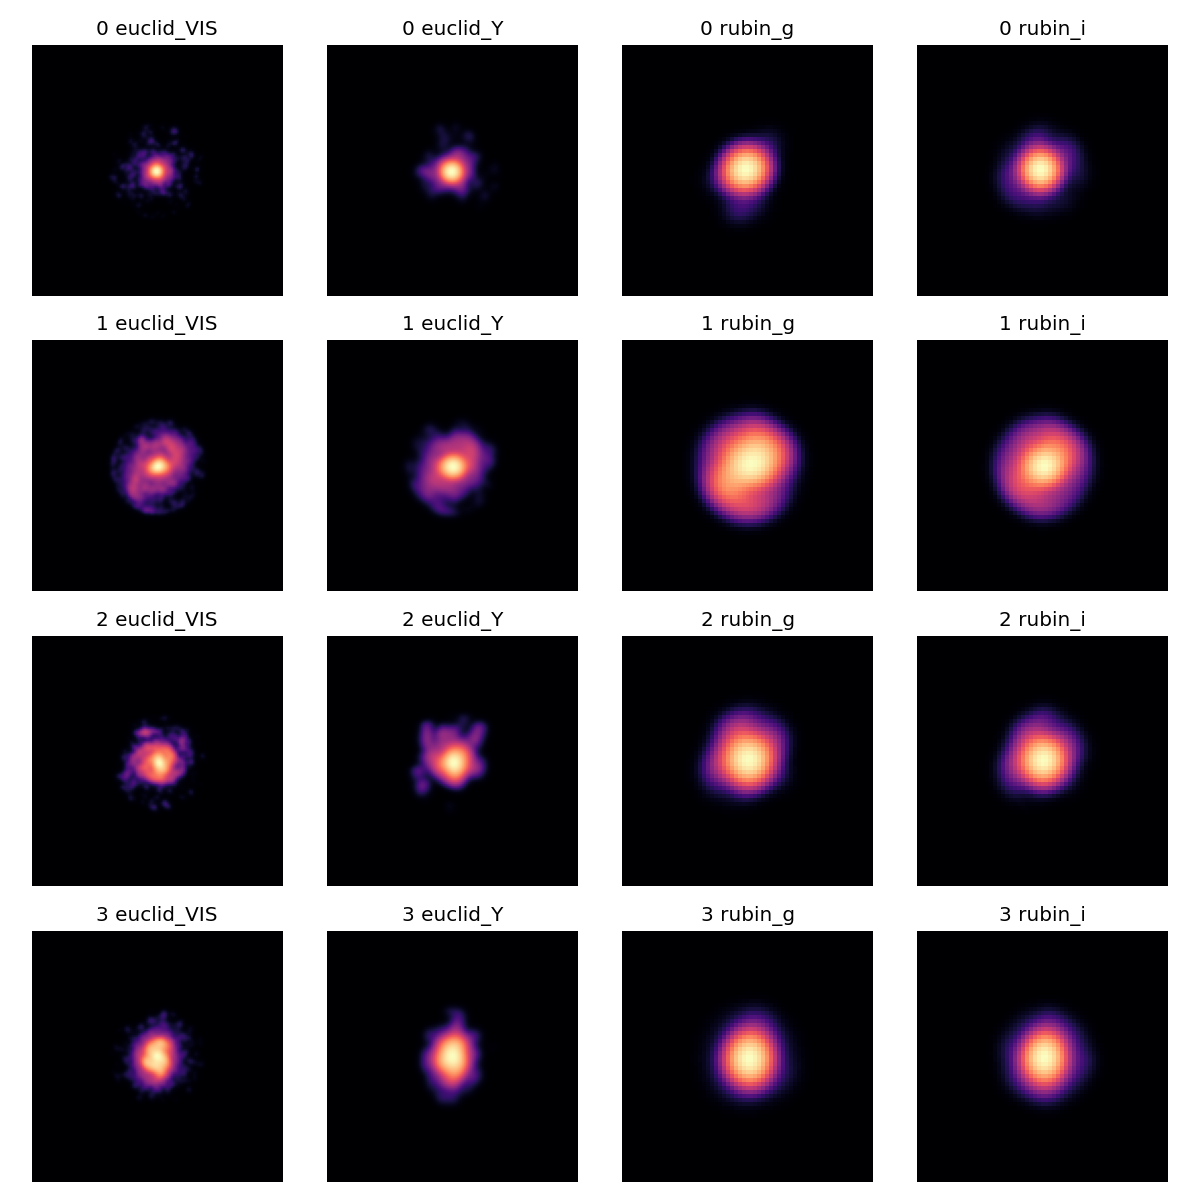

In [2]:
display(pd.read_csv(OUT/'donor_bands.csv').groupby('band').agg(donors=('donor','nunique'),median_donor_snr=('snr','median'),weak_morphology_fraction=('fallback','mean'),median_reconstruction_chi2=('reconstruction_chi2','median')))
display(Image(filename=str(OUT/'figures/empirical_morphologies.png')))

## Measured flux versus true injected flux

The curves compare **foundation (blue)**, **Tractor (green)** and the **oracle (gray)** on the same central-source list in each of the ten bands. Each solid curve shows median measured flux in shared bins of true flux, located at the bin’s median true flux. The shading spans the **16th–84th percentiles** of measured flux: the central 68% distribution, approximately ±1σ for a Gaussian. This shows the distribution within each true-flux bin, not a confidence interval on the median or a formal fit error. The dashed diagonal means perfect recovery.

The first figure includes all qualified central sources. The second selects nominal **true S/N 1–10**, the same faint sample used for the primary score; selection never uses measured flux. Individual dots are omitted. All signed measurements, including negative values and outliers, enter the medians and percentiles. Both axes use the same asinh display scale per band, which is approximately linear near zero and logarithmic at large absolute flux; tick values remain in native flux units. The underlying measurements and plotted summaries are saved in `flux_scatter_points.csv` and `flux_scatter_summary.csv`, with PNG and PDF figures in `figures/`.

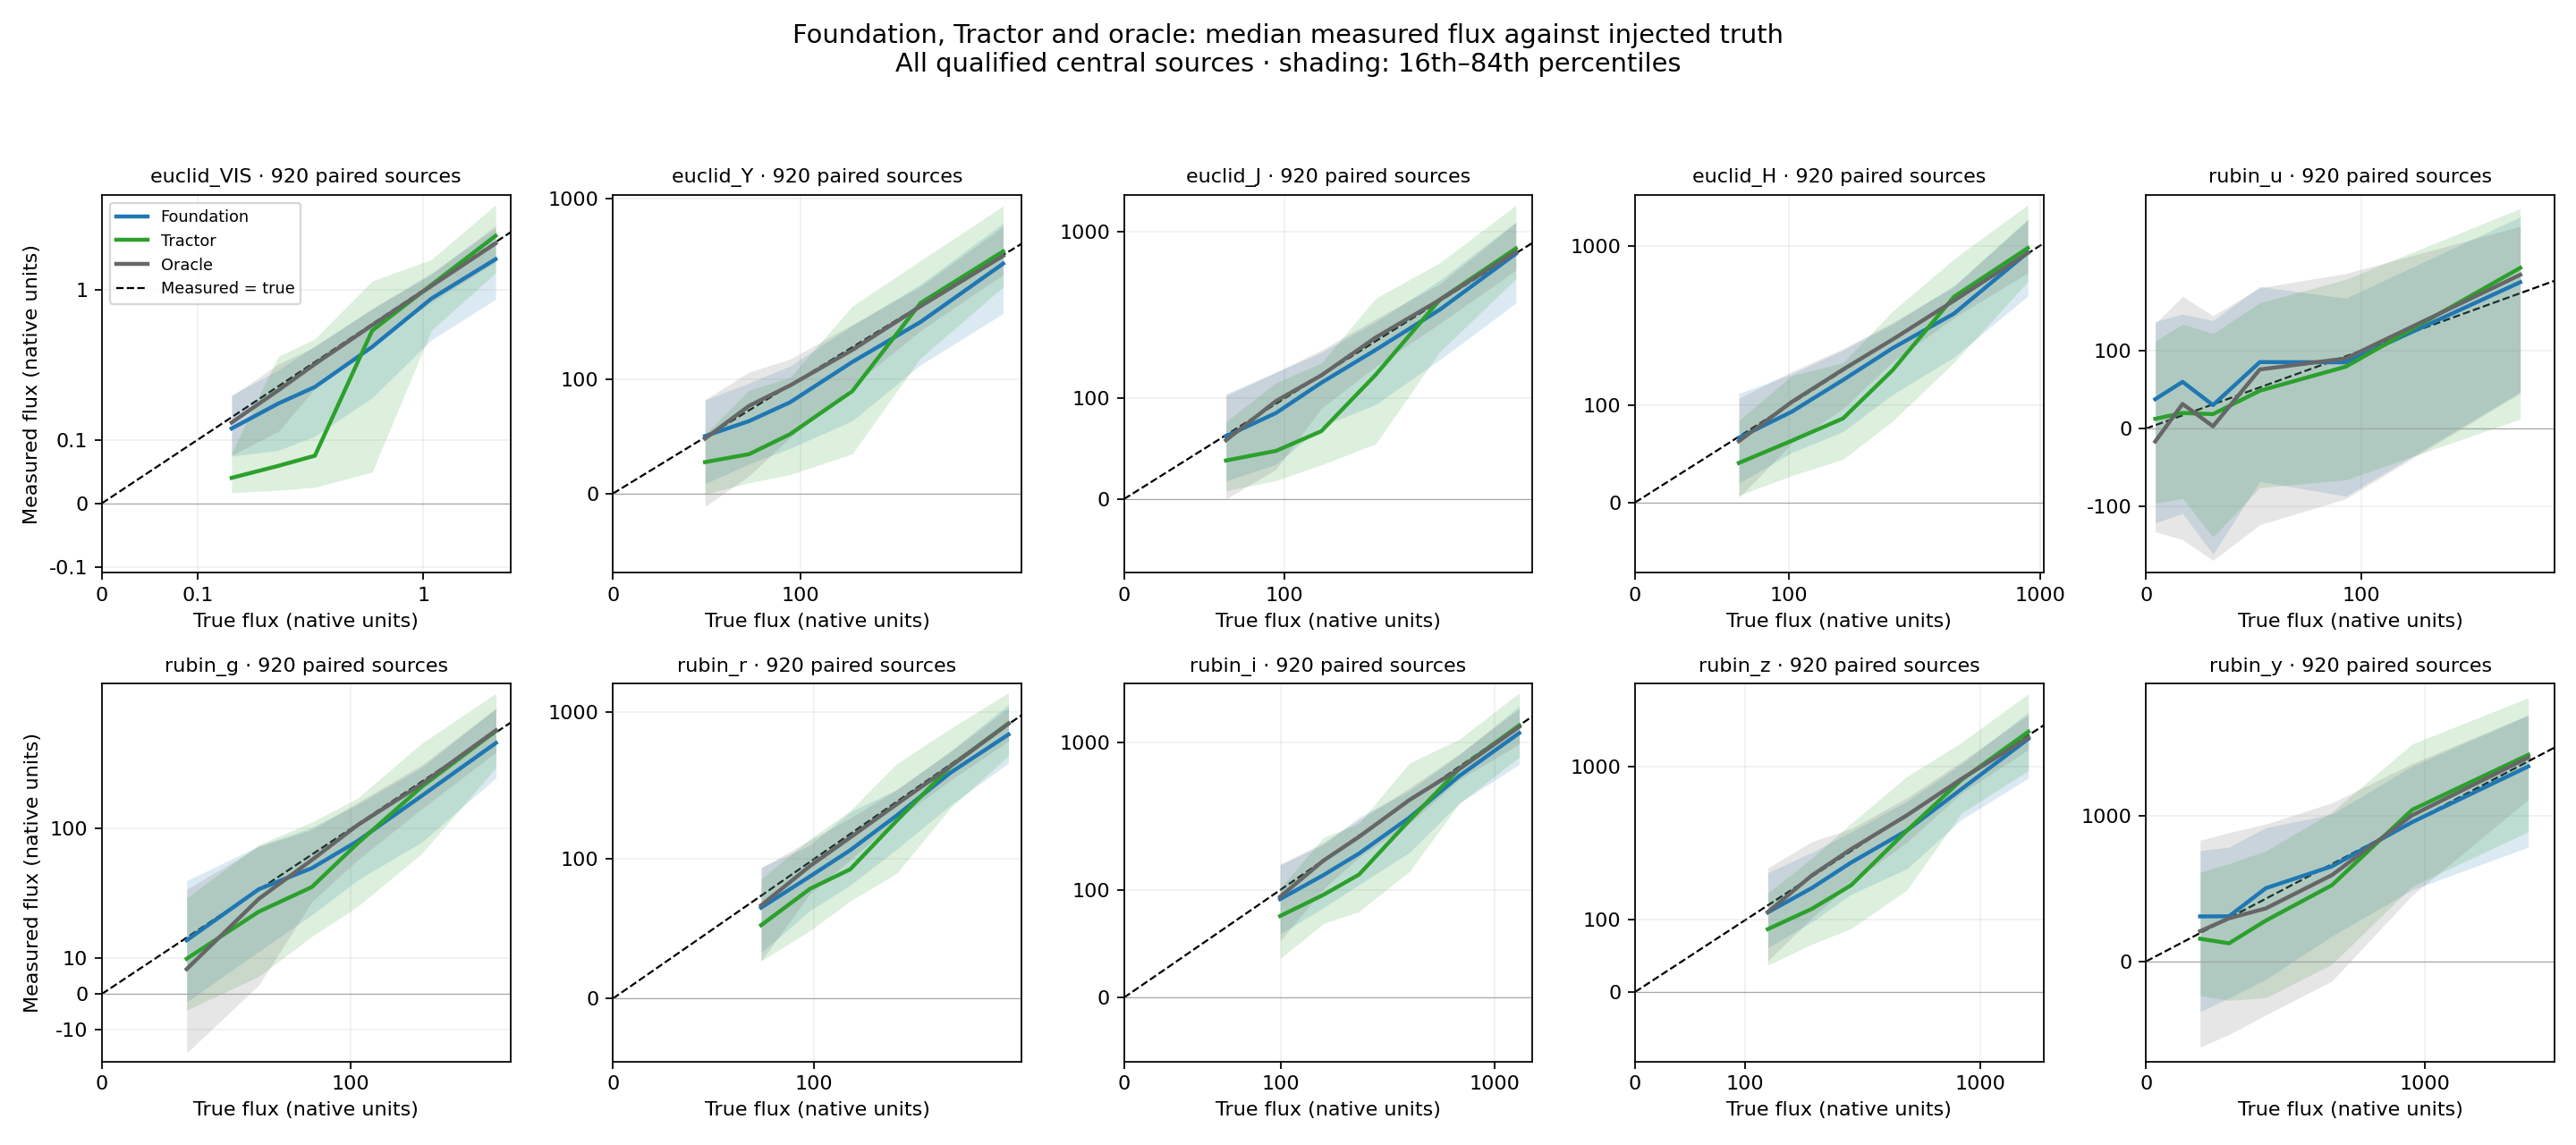

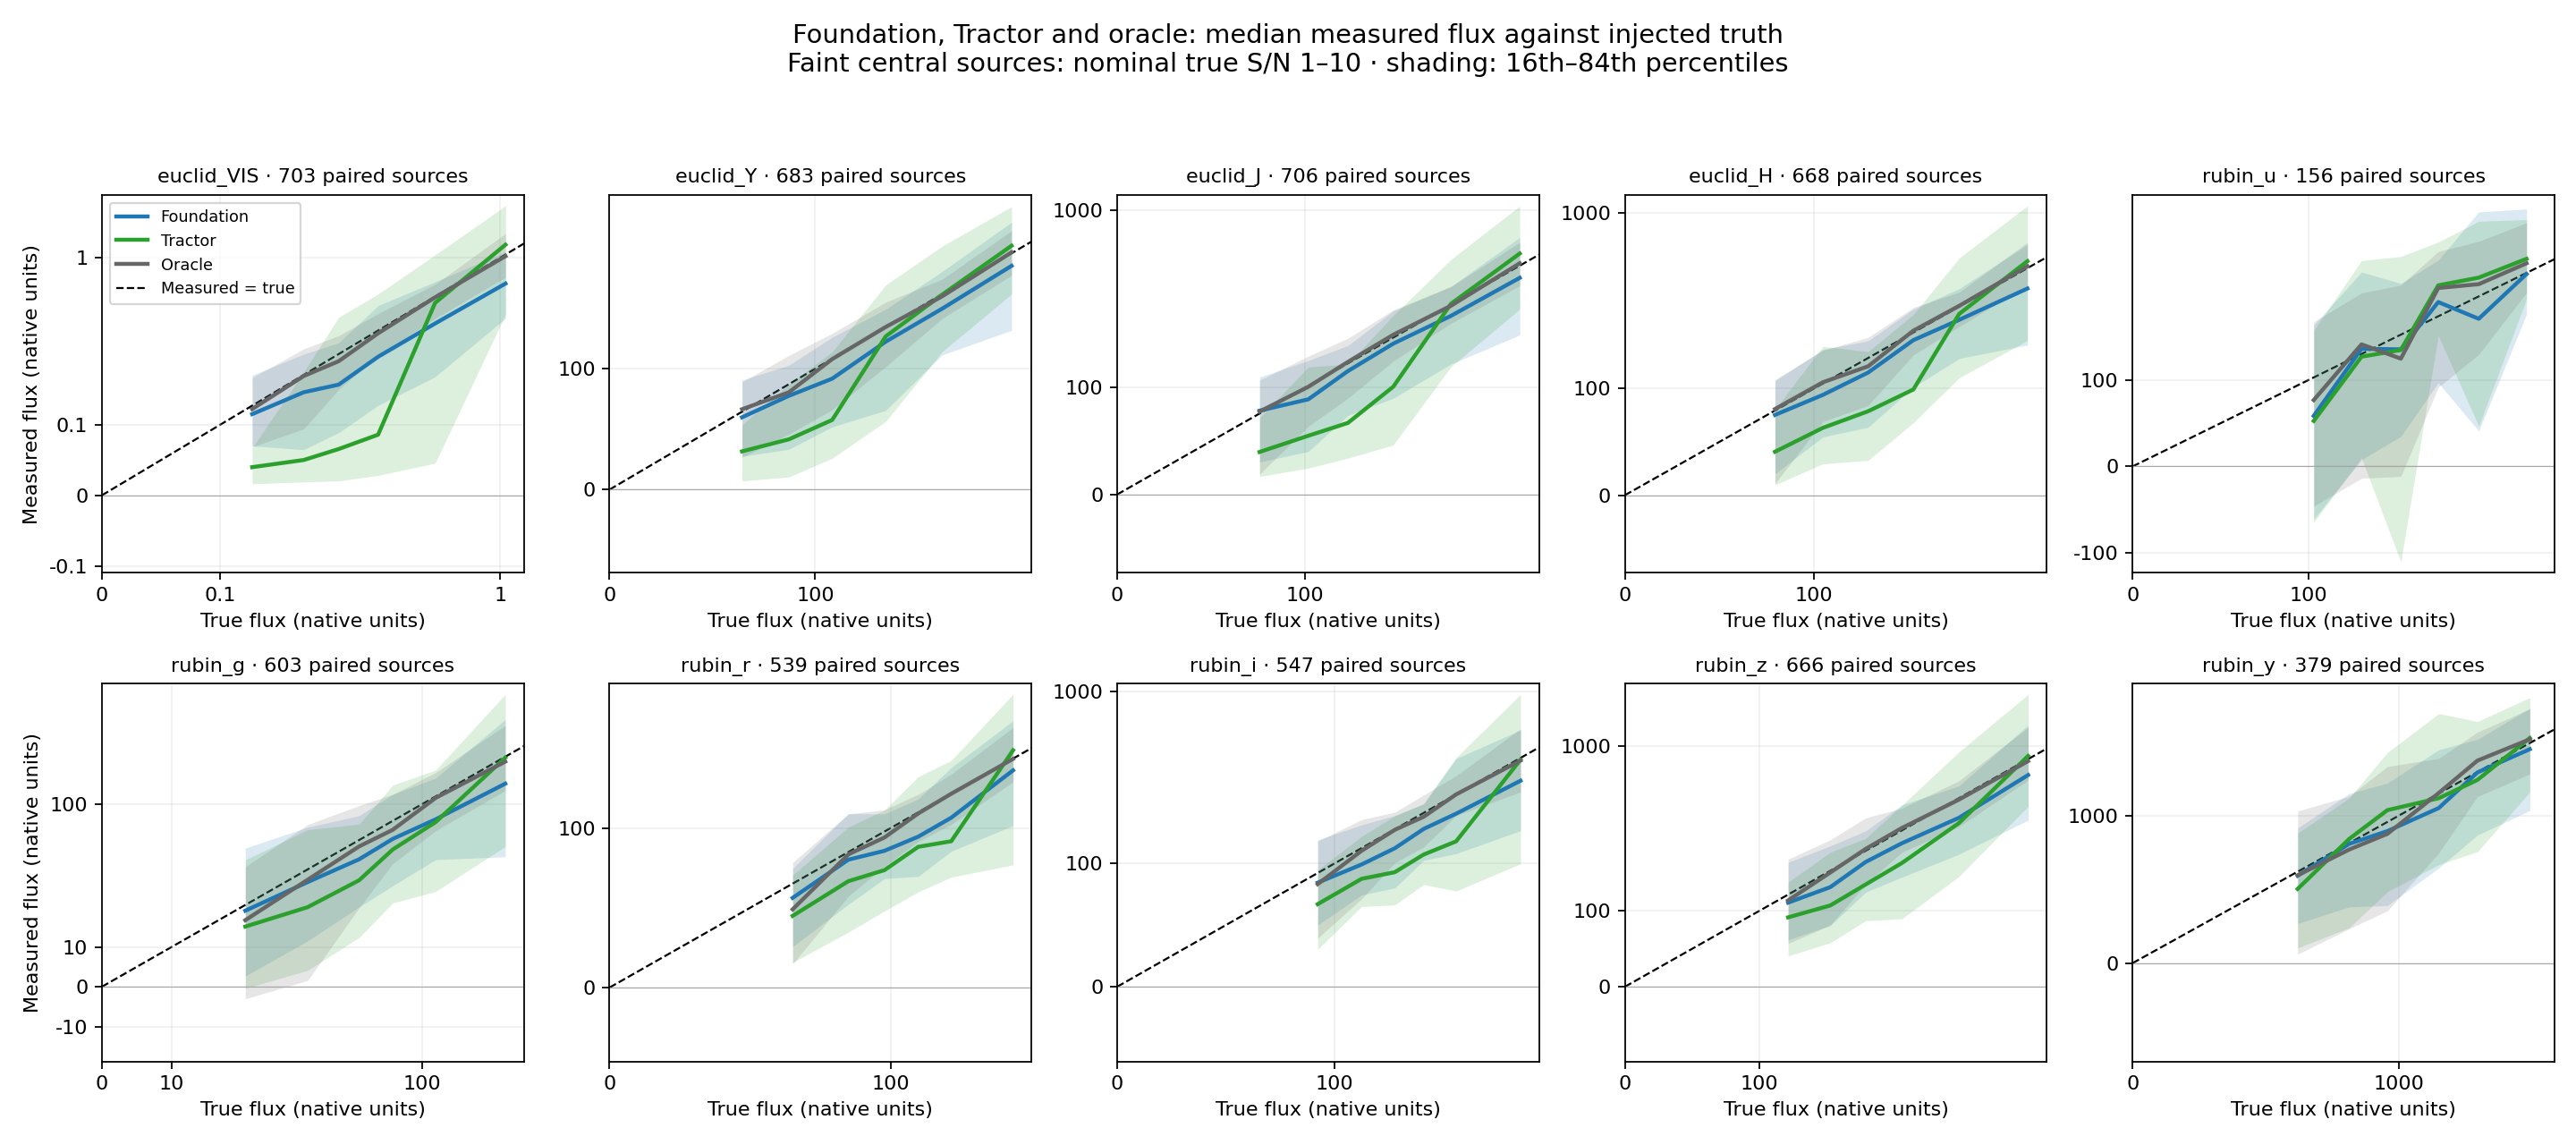

In [3]:
display(Image(filename=str(OUT/'figures/flux_scatter_all.png')))
display(Image(filename=str(OUT/'figures/flux_scatter_faint.png')))

## What is the oracle?

The **oracle is a diagnostic fit that knows the exact injected shape of every source in every band**, including its clumps, color gradients, PSF and position. It fits the **unknown flux amplitudes and a constant sky level** jointly on the same noisy, masked images. It is not handed the true fluxes and can still return noisy or negative measurements.

Foundation and Tractor must estimate morphology from the images. The oracle skips that estimation, so it gives a reference for performance when the morphology is known perfectly. If the oracle also fails, background contamination, noise modeling or blending can be responsible. If it recovers flux well while a competitor does not, the fitted morphology or its refinement is a likely source of the extra error.

This privileged fit cannot be used on real galaxies whose shapes are unknown. Its errors condition on the exact templates and use the supplied diagonal variance; they do not account fully for correlated coadd noise. Its gray median curve and percentile shading appear alongside the two photometers as a diagnostic reference.

## Paired flux recovery

Signed fluxes, including negative measurements, are retained. Nominal true S/N uses an independent linear fit of exact injected templates and includes neighbor plus constant-background covariance, with the supplied diagonal variance maps. Actual coadd correlations are preserved in the images. The primary comparison is `central_faint_clean`: central sources with nominal true S/N 1–10, with donor QA applied to both target and injected neighbor. QA requires a unique independent MER galaxy match (point-like probability ≤0.2), a non-VIS counterpart at S/N ≥8, and a donor center correction ≤0.5 arcsec. These cuts use donor data only, never recovery outcomes. Every candidate remains in the all-trial comparison. Per-band/context tables use the clean scenes.

Flux errors are also shown in noise units to avoid unstable division by very faint true flux. All primary rows require every method to succeed; failures are reported above. Negative paired absolute-error differences favor the foundation head. Bootstrap donor identities and background regions separately; repeated injections are not independent new galaxies. These intervals are exploratory, especially with seven sky fields.

,model,n,n_donors,n_background_regions,bias_sigma,rmse_sigma,mean_abs_sigma,median_abs_sigma,outlier_5sigma,median_fractional_bias,fractional_rmse,pull_rms,coverage_1sigma,negative_fraction
0,foundation,5650.0,95.0,7.0,-0.464560,2.565024,1.690905,1.142667,0.046549,-0.172001,0.772691,3.230352,0.401770,0.028496
3,tractor_vis,5650.0,95.0,7.0,-0.040185,4.929648,2.672928,1.690789,0.106372,-0.356977,1.278522,6.676188,0.205664,0.051327


,model,band,n,n_donors,n_background_regions,bias_sigma,rmse_sigma,mean_abs_sigma,median_abs_sigma,outlier_5sigma,median_fractional_bias,fractional_rmse,pull_rms,coverage_1sigma,negative_fraction
0,foundation,euclid_H,668.0,95.0,7.0,-0.450014,3.003014,1.712258,1.088322,0.046407,-0.140325,0.772887,3.713460,0.444611,0.040419
1,foundation,euclid_J,706.0,95.0,7.0,-0.376040,2.443706,1.521243,1.003534,0.036827,-0.109112,0.663866,3.061882,0.468839,0.024079
2,foundation,euclid_VIS,703.0,95.0,7.0,-0.749355,2.700508,1.862720,1.356294,0.064011,-0.261785,0.723114,4.262332,0.339972,0.011380
3,foundation,euclid_Y,683.0,95.0,7.0,-0.365993,2.099726,1.382969,0.905356,0.032211,-0.159032,0.662937,2.457282,0.486091,0.035139
4,foundation,rubin_g,603.0,95.0,7.0,-0.544987,2.990901,2.123382,1.488903,0.074627,-0.223123,1.050743,3.504929,0.316750,0.044776
5,foundation,rubin_i,547.0,94.0,7.0,-0.599217,2.595607,1.865103,1.334196,0.054845,-0.197544,0.610742,3.088734,0.314442,0.007313
6,foundation,rubin_r,539.0,94.0,7.0,-0.501678,3.051849,2.114273,1.584205,0.072356,-0.204296,0.787254,3.486392,0.302412,0.018553
7,foundation,rubin_u,156.0,64.0,7.0,0.135543,2.097156,1.456197,0.995013,0.038462,-0.022940,1.341375,2.274866,0.455128,0.115385
8,foundation,rubin_y,379.0,94.0,7.0,-0.130116,1.500391,1.068623,0.784662,0.007916,-0.078822,0.741338,1.737640,0.522427,0.042216
9,foundation,rubin_z,666.0,95.0,7.0,-0.490885,2.176997,1.515596,1.065679,0.024024,-0.183008,0.674033,2.768117,0.414414,0.015015


,selection,competitor,n,n_donors,n_background_regions,mean_abs_error_delta_sigma,donor_bootstrap_95,background_bootstrap_95,donor_background_bootstrap_95,foundation_rmse_sigma,competitor_rmse_sigma
1,central_all,tractor_vis,10000,100,7,-0.935874,"[-1.2293806290244602, -0.6589942356941142]","[-1.1036932995743347, -0.7588759054150963]","[-1.3482699445401243, -0.5336170930097163]",5.881643,7.224194
3,central_faint,tractor_vis,6064,100,7,-0.887693,"[-1.1119018638433869, -0.6545039783853331]","[-1.0476419203799519, -0.6971052532472771]","[-1.218893185178815, -0.5108384059156555]",4.604798,5.152726
5,central_faint_clean,tractor_vis,5650,95,7,-0.982024,"[-1.2081844942722089, -0.7787499525372928]","[-1.08788770335979, -0.8834809839792398]","[-1.2810817891365756, -0.7005114866810823]",2.565024,4.929648
7,central_VIS_faint,tractor_vis,771,100,7,-1.226235,"[-1.4442100912590812, -0.9958788971137896]","[-1.3850745420203665, -1.0757008118369384]","[-1.6031810973960174, -0.897521561146845]",3.522479,4.878798
9,strong_band_morphology_faint,tractor_vis,6058,100,7,-0.888290,"[-1.1125588163989635, -0.6549054950792009]","[-1.0484339794210433, -0.6971835419683298]","[-1.2194102473381838, -0.5109973686020362]",4.606666,5.154770


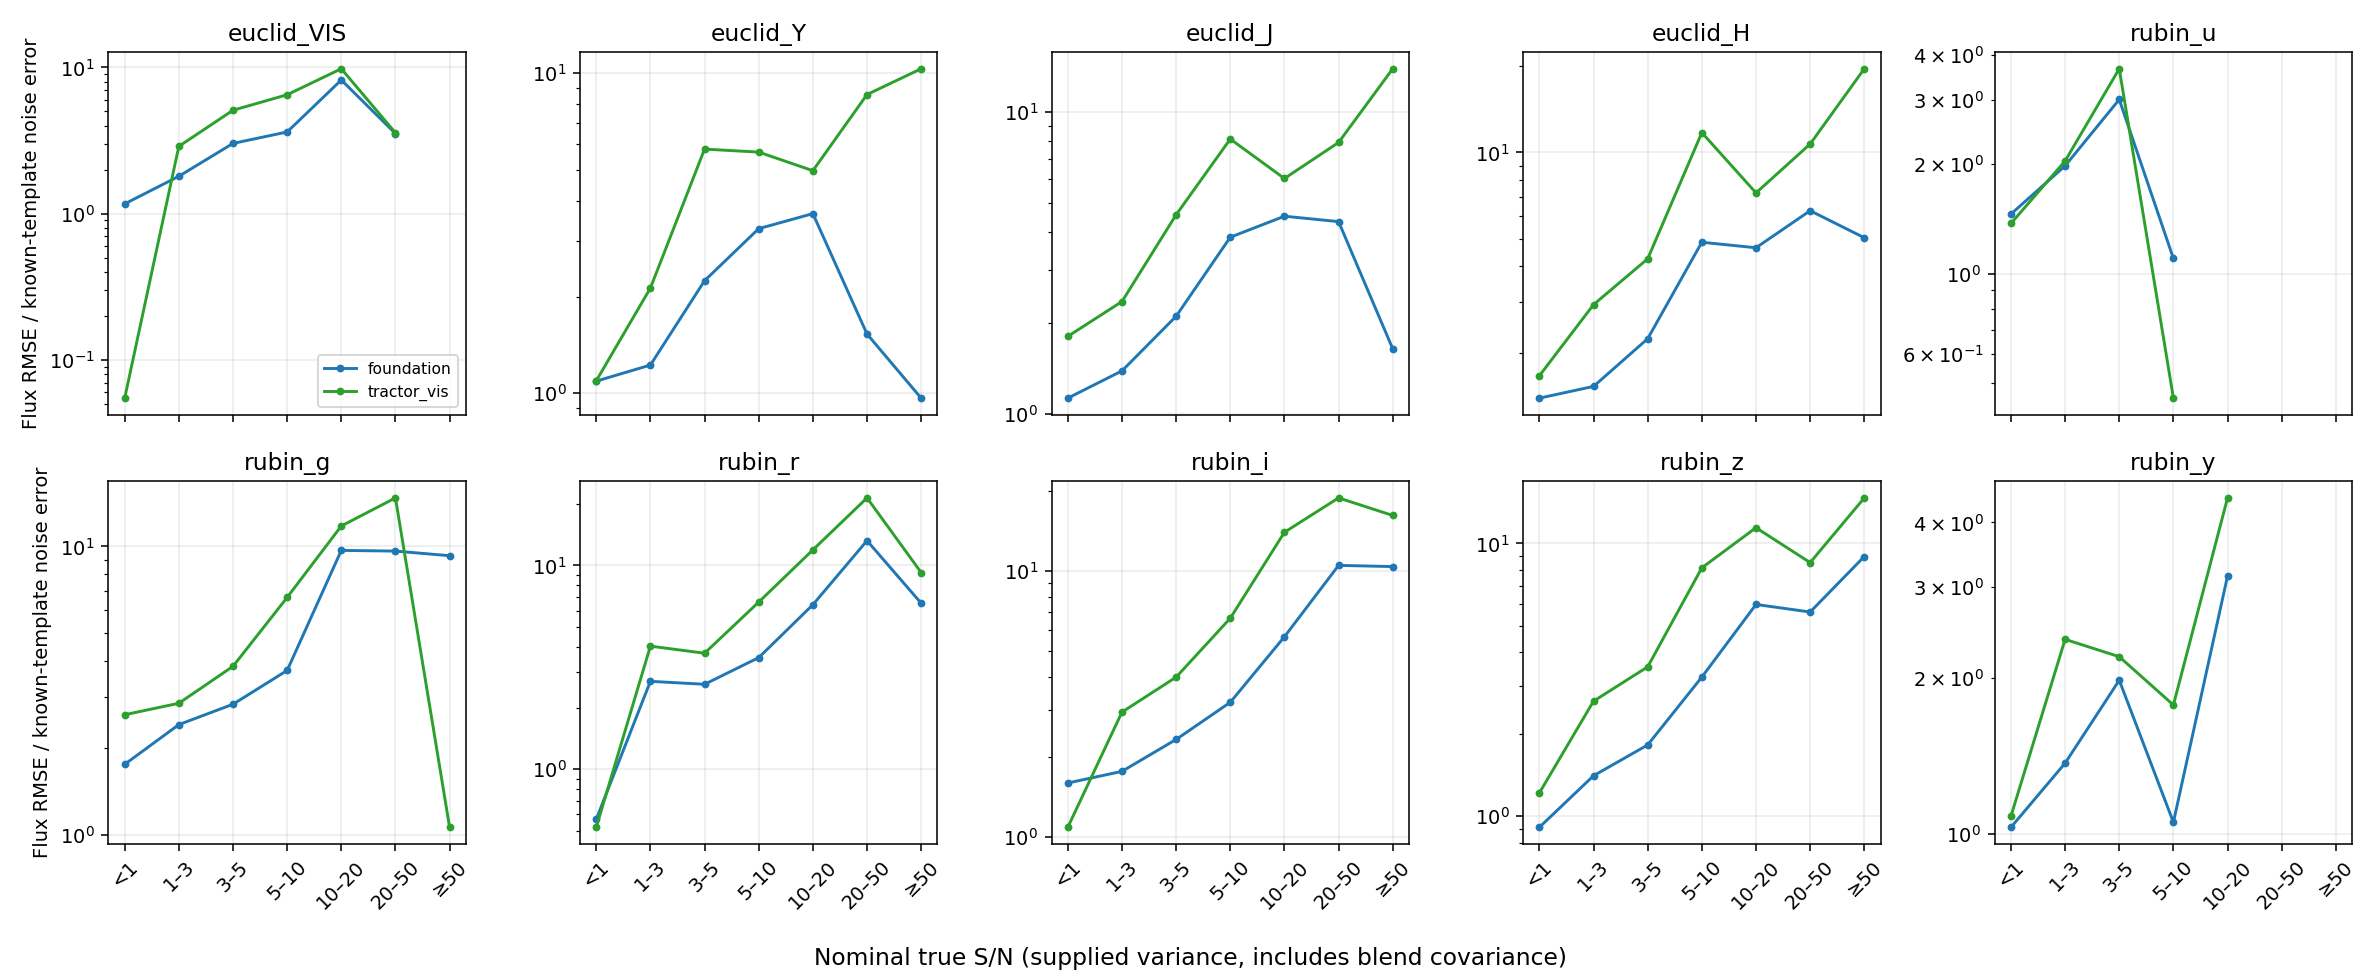

,model,band,n,n_donors,n_background_regions,bias_sigma,rmse_sigma,mean_abs_sigma,median_abs_sigma,outlier_5sigma,median_fractional_bias,fractional_rmse,pull_rms,coverage_1sigma,negative_fraction
0,foundation,euclid_H,920.0,95.0,7.0,-0.465891,3.428207,1.995680,1.152053,0.081522,-0.089117,0.962348,4.258843,0.430435,0.036957
1,foundation,euclid_J,920.0,95.0,7.0,-0.402320,2.725023,1.689232,1.029629,0.059783,-0.084323,0.815563,3.425314,0.455435,0.030435
2,foundation,euclid_VIS,920.0,95.0,7.0,-0.837644,4.481417,2.686581,1.573888,0.135870,-0.206250,0.677320,6.597909,0.291304,0.008696
3,foundation,euclid_Y,920.0,95.0,7.0,-0.306738,2.100260,1.346439,0.830057,0.036957,-0.132554,0.962153,2.593034,0.520652,0.045652
4,foundation,rubin_g,920.0,95.0,7.0,-0.744805,5.369984,2.870421,1.720206,0.143478,-0.166273,1.321707,6.692659,0.304348,0.056522
5,foundation,rubin_i,920.0,95.0,7.0,-1.193788,5.638021,3.311297,2.008925,0.184783,-0.159424,0.538644,6.585926,0.247826,0.008696
6,foundation,rubin_r,920.0,95.0,7.0,-1.096154,6.905201,3.802508,2.306198,0.214130,-0.155901,0.671371,8.257904,0.227174,0.013043
7,foundation,rubin_u,920.0,95.0,7.0,0.083929,1.584776,1.150771,0.866487,0.013043,0.320172,43.309956,1.613015,0.525000,0.283696
8,foundation,rubin_y,920.0,95.0,7.0,0.002983,1.261032,0.890435,0.668874,0.004348,0.020821,2.460348,1.431569,0.602174,0.140217
9,foundation,rubin_z,920.0,95.0,7.0,-0.707039,3.448852,2.120048,1.270240,0.079348,-0.143491,0.648781,4.224105,0.369565,0.015217


In [4]:
shown = ['foundation', 'tractor_vis']
for filename in ['primary_overall.csv', 'primary_by_band.csv']:
    table = pd.read_csv(OUT/filename)
    display(table[table.model.isin(shown)])
comparisons = pd.DataFrame(json.loads((OUT/'paired_comparisons.json').read_text()))
display(comparisons[comparisons.competitor=='tractor_vis'])
display(Image(filename=str(OUT/'figures/flux_recovery.png')))
table = pd.read_csv(OUT/'by_band.csv')
display(table[table.model.isin(shown)])

## Blends and uncertainty calibration

Contexts include isolated objects, equal-VIS-flux neighbors, a 10× brighter VIS neighbor, and neighbors with a different empirical SED at 3× VIS flux. Separations span 0.35, 0.7 and 1.4 arcsec. Background source cores are masked identically for every method; uncataloged sky sources remain.

The initial catalog-only sky pilot (`runs/empirical_injection_pilot`) contained bright Rubin objects missing in VIS catalogs. Even the exact-template oracle failed there. The revised v2 sky pool uses independent secure detections in every native band and grows their isophotes before selecting injection locations; the models and galaxy library remain fixed.

The oracle helps expose covariance limitations: its Euclid residual scatter is about one supplied error, while Rubin scatters are wider. The competitors’ errors condition on their chosen morphology and ignore coadd correlations; coverage is measured rather than assumed.

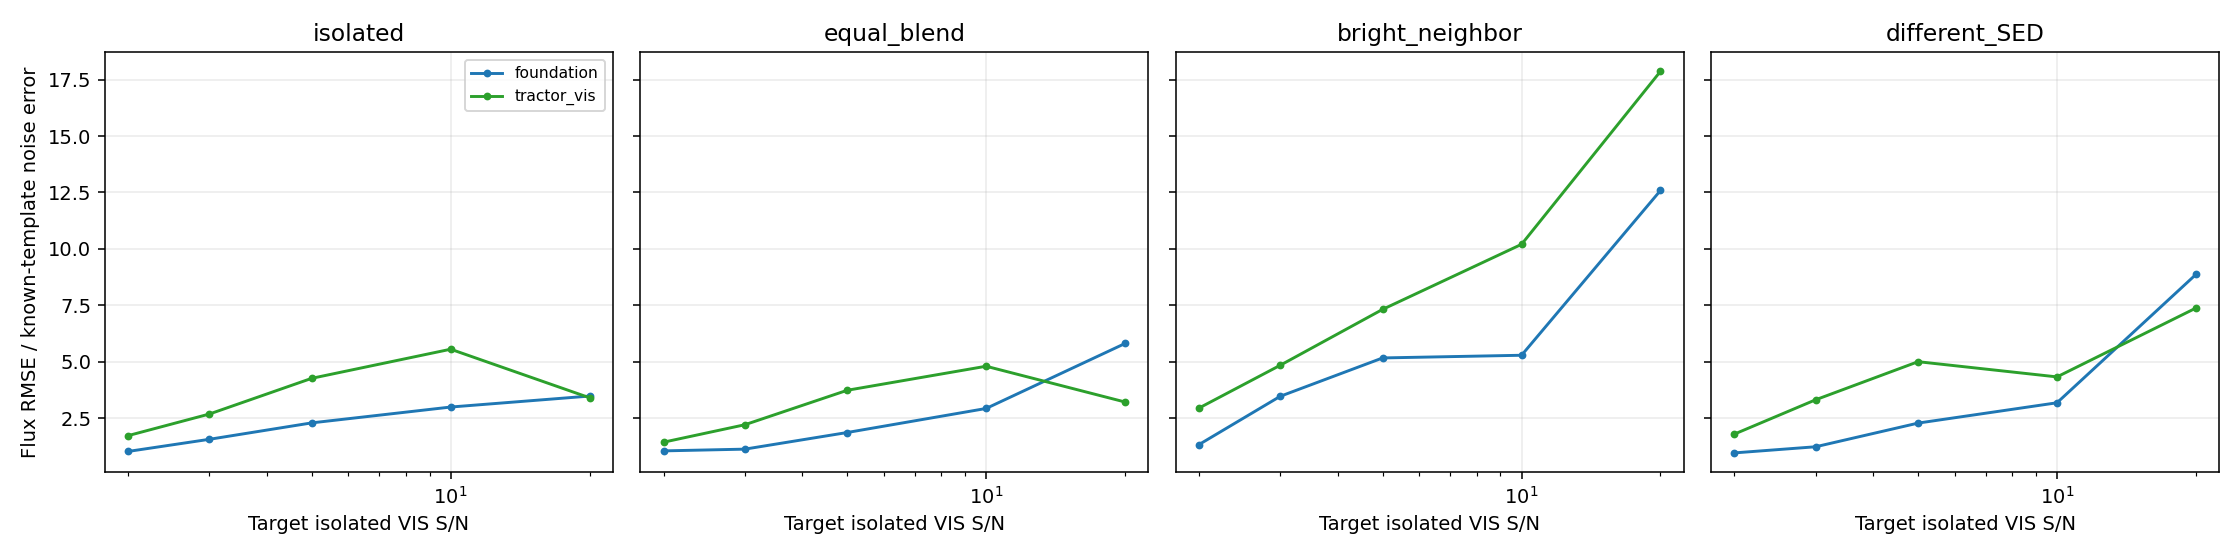

,model,context,n,n_donors,n_background_regions,bias_sigma,rmse_sigma,mean_abs_sigma,median_abs_sigma,outlier_5sigma,median_fractional_bias,fractional_rmse,pull_rms,coverage_1sigma,negative_fraction
0,foundation,bright_neighbor,2260.0,89.0,7.0,0.146055,6.518833,3.365141,1.641639,0.184956,-0.019743,22.915817,8.303309,0.344690,0.078761
1,foundation,different_SED,2280.0,88.0,7.0,-0.580694,3.669282,2.118587,1.166551,0.098246,-0.088852,7.055670,4.152226,0.417982,0.062281
2,foundation,equal_blend,2310.0,91.0,7.0,-0.697205,2.585310,1.634210,1.007974,0.054978,-0.143230,11.417130,3.102162,0.452814,0.062338
3,foundation,isolated,2350.0,92.0,7.0,-1.110480,2.293454,1.661156,1.184604,0.045957,-0.167552,7.586550,2.982687,0.373617,0.052766
12,tractor_vis,bright_neighbor,2260.0,89.0,7.0,3.350488,12.515663,5.950128,2.161025,0.277876,0.219012,15.850620,12.739598,0.230973,0.111504
13,tractor_vis,different_SED,2280.0,88.0,7.0,0.005235,4.445479,2.672874,1.465352,0.140789,-0.231201,5.667242,5.773428,0.266667,0.100439
14,tractor_vis,equal_blend,2310.0,91.0,7.0,-0.624615,2.892029,1.902299,1.248918,0.074026,-0.286752,8.545036,5.645747,0.283117,0.085281
15,tractor_vis,isolated,2350.0,92.0,7.0,-1.693218,3.727124,2.518999,1.709794,0.114894,-0.417702,6.251125,7.521203,0.225957,0.080000


In [5]:
display(Image(filename=str(OUT/'figures/blend_recovery.png')))
table = pd.read_csv(OUT/'by_context.csv')
display(table[table.model.isin(shown)])

## Limits and next experiment

No effective gain is available in cached mosaic headers: the default run preserves actual sky noise but adds no source shot noise. This matters for bright neighbors. A calibrated native-unit gain map can enable the explicit coadd Poisson approximation; a full detector-level treatment needs the exposures and weights.

Expand the donor library using deeper data, validate nonparametric reconstructions against deeper independent images, obtain spatial Rubin PSFs, and add detection/centering errors. For a MER comparison, run MER extraction on the identical injected images; the existing catalog cannot measure injected objects. Keep this pilot frozen if tuning a new head; generate a separate final test split.

In [6]:
display(pd.Series(summary['limitations']).to_frame('limitation'))
display(json.loads((OUT/'protocol.json').read_text()))

,limitation
0,"Not added: faint, sky-dominated pilot; no cali..."
1,Known positions; detection and completeness no...
2,Approximate intrinsic donor reconstruction; fa...
3,Rubin PSFs are approximate Gaussian calibrations
4,Real coadd correlations remain; diagonal covar...
5,Catalog masking leaves uncataloged sources and...
6,Only seven independent background fields; boot...
7,Foundation pretraining independence from donor...
8,MER not rerun on injections; no claim of beati...


{'version': 'empirical_pilot_v2',
 'seed': 20261004,
 'n_scenes': 1000,
 'background_regions': [3, 7, 11, 15, 19, 23, 27],
 'donor_snr_min': 25.0,
 'units': 'Each native band; measured donor colors dimmed by a common scalar',
 'donor_model': 'Independent positive FISTA pixels, Gaussian likelihood, fixed smoothness .04 / sparsity .15 in sky-RMS units, support 2.3 arcsec',
 'weak_bands': 'Data-only common VIS-shape amplitude when SNR<8; truncated-positive posterior mean, individually flagged',
 'psf': 'Archive local Euclid pixel PSF; calibrated approximate Gaussian Rubin PSF; rotation of source+PSF, optional extra Gaussian blur; GalSim no_pixel',
 'noise': 'Real masked coadd sky, including its existing correlations; no stochastic donor-noise copies',
 'blank_sky': 'All-band independent SEP detections at 3 local empirical RMS, minimum area 10 and integrated SNR>10; grow isophotes 1.5 arcsec and exclude centers within 4 arcsec; retain faint undetected sky',
 'source_noise': 'Not added: fai